In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os

PROJECT_DIR = "/content/drive/MyDrive/cisc886-retail-chatbot"
CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints"
FINAL_DIR = f"{PROJECT_DIR}/final_lora"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FINAL_DIR, exist_ok=True)

print("Checkpoint dir:", CHECKPOINT_DIR)

Checkpoint dir: /content/drive/MyDrive/cisc886-retail-chatbot/checkpoints


In [3]:
!pip install -q unsloth
!pip install -q --no-deps trl peft accelerate bitsandbytes datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/22

In [2]:
from datasets import load_dataset

data_files = {
    "train": "/content/retail_train.jsonl",
    "validation": "/content/retail_eval.jsonl",
}

dataset = load_dataset("json", data_files=data_files)

print(dataset)
print(dataset["train"][0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 16234
    })
    validation: Dataset({
        features: ['messages'],
        num_rows: 1766
    })
})
{'messages': [{'role': 'system', 'content': 'You are a helpful ecommerce shopping assistant trained on historical retail transactions. Help with product questions, order-style inquiries, cancellations, returns, and product recommendations. Use only the provided historical context. Do not invent live inventory, shipping status, or real-time prices.'}, {'role': 'user', 'content': 'What does invoice 537000 mean?'}, {'role': 'assistant', 'content': 'Invoice 537000 appears to be a cancellation, return, or adjustment record in the historical data. Related item descriptions include: Unknown item.'}]}


In [5]:
# This is just a test size. the final model would be 10x times
TRAIN_SIZE = min(60000, len(dataset["train"]))
EVAL_SIZE = min(5000, len(dataset["validation"]))

train_data = dataset["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
eval_data = dataset["validation"].shuffle(seed=42).select(range(EVAL_SIZE))

print("Train examples:", len(train_data))
print("Eval examples:", len(eval_data))

Train examples: 16234
Eval examples: 1766


In [6]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 1024
dtype = None
load_in_4bit = True

model_name = "unsloth/Llama-3.2-1B-Instruct"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


In [7]:
def formatting_prompts_func(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

train_data = train_data.map(formatting_prompts_func)
eval_data = eval_data.map(formatting_prompts_func)

print(train_data[0]["text"][:1500])

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 28 Apr 2026

You are a helpful ecommerce shopping assistant trained on historical retail transactions. Help with product questions, order-style inquiries, cancellations, returns, and product recommendations. Use only the provided historical context. Do not invent live inventory, shipping status, or real-time prices.<|eot_id|><|start_header_id|>user<|end_header_id|>

What is in order invoice 557333?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Invoice 557333 contains 2 unique product(s): TEA TIME PARTY BUNTING x8 at £4.95; PARTY BUNTING x150 at £4.15. Estimated historical total: £662.10.<|eot_id|>


In [8]:
from unsloth import FastLanguageModel
import pandas as pd
import torch

FastLanguageModel.for_inference(model)

SYSTEM_PROMPT = (
    "You are a helpful ecommerce shopping assistant trained on historical retail transactions. "
    "Help with product questions, order-style inquiries, cancellations, returns, and product recommendations. "
    "Use only the provided historical context. Do not invent live inventory, shipping status, or real-time prices."
)

test_prompts = [
    "I like WHITE HANGING HEART T-LIGHT HOLDER. Recommend similar or complementary products.",
    "What does a cancelled invoice mean in this retail dataset?",
    "Tell me about JUMBO BAG RED RETROSPOT.",
]

def generate_answer(user_prompt, max_new_tokens=180):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        use_cache=True,
    )

    new_tokens = outputs[:, inputs.input_ids.shape[1]:]
    return tokenizer.batch_decode(new_tokens, skip_special_tokens=True)[0].strip()

base_rows = []

for prompt in test_prompts:
    response = generate_answer(prompt)
    base_rows.append({"prompt": prompt, "base_response": response})
    print("=" * 100)
    print("PROMPT:", prompt)
    print("BASE RESPONSE:", response)

base_df = pd.DataFrame(base_rows)
base_df.to_csv(f"{PROJECT_DIR}/base_model_responses.csv", index=False)

Both `max_new_tokens` (=180) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

PROMPT: I like WHITE HANGING HEART T-LIGHT HOLDER. Recommend similar or complementary products.
BASE RESPONSE: Based on your interest in WHITE HANGING HEART T-LIGHT HOLDER, I recommend the following similar or complementary products:

1. **Silver Heart-Shaped Wall Decor**: A beautiful and elegant piece that combines the classic design of heart-shaped decorations with a modern twist.
2. **Whimsical Floral Decor**: A charming set of wall decor featuring colorful flowers and vines, perfect for adding a touch of whimsy to any room.
3. **Cute and Cozy Throw Pillows**: A set of adorable throw pillows with a heart-themed design that can add a pop of color and personality to your room.
4. **Personalized Photo Frame**: A beautiful frame that allows you to display a special memory or loved one, with a heart-shaped design that adds a touch of warmth and sentimentality.
5. **Wall Art with Quote**: A stunning piece of wall art featuring a heart-themed quote


Both `max_new_tokens` (=180) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT: What does a cancelled invoice mean in this retail dataset?
BASE RESPONSE: Based on the provided historical retail dataset, a cancelled invoice typically means that a customer has requested a product or service that was not fulfilled or did not meet their expectations.
PROMPT: Tell me about JUMBO BAG RED RETROSPOT.
BASE RESPONSE: I couldn't find any information on a specific product called "JUMBO BAG RED RETROSPOT" in my available historical context. However, I can suggest some possible sources where you might be able to find this product:

1. **Department Stores**: I can try searching for this product in department stores that carry travel or outdoor gear. Some examples include Target, Walmart, or specialty stores like REI.
2. **Online Retailers**: You can also try searching online retailers like Amazon, eBay, or Zappos. They might have this product in their inventory.
3. **Specialty Stores**: If you're looking for this product in a specific category, like outdoor gear or lugga

In [9]:
from unsloth import FastLanguageModel

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

Unsloth 2026.4.8 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


In [10]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported
from pathlib import Path

def get_last_checkpoint(output_dir):
    output_dir = Path(output_dir)
    checkpoints = list(output_dir.glob("checkpoint-*"))
    if not checkpoints:
        return None

    def checkpoint_step(path):
        return int(path.name.split("-")[-1])

    latest = max(checkpoints, key=checkpoint_step)
    return str(latest)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_data,
    eval_dataset=eval_data,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=True,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,

        # Finishable training target.
        max_steps=5000,

        warmup_steps=20,
        learning_rate=2e-4,

        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),

        logging_steps=10,
        eval_strategy="steps",
        eval_steps=100,

        save_strategy="steps",
        save_steps=50,
        save_total_limit=3,

        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,

        output_dir=CHECKPOINT_DIR,
        report_to="none",
    ),
)

last_checkpoint = get_last_checkpoint(CHECKPOINT_DIR)
print("Last checkpoint:", last_checkpoint)

trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/6000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/500 [00:00<?, ? examples/s]

Last checkpoint: None


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,000 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
100,0.787283,0.709380
200,0.582811,0.569064
300,0.519766,0.496639
400,0.474643,0.457298
500,0.458409,0.439942


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/cisc886-retail-chatbot/checkpoints/checkpoint-50/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `

In [11]:
model.save_pretrained(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)

print("Saved final LoRA adapter to:", FINAL_DIR)

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/cisc886-retail-chatbot/final_lora/tokenizer_config.json.


Saved final LoRA adapter to: /content/drive/MyDrive/cisc886-retail-chatbot/final_lora


In [12]:
FastLanguageModel.for_inference(model)

ft_rows = []

for row in base_rows:
    prompt = row["prompt"]
    response = generate_answer(prompt)

    ft_rows.append({
        "prompt": prompt,
        "base_response": row["base_response"],
        "fine_tuned_response": response,
    })

    print("=" * 100)
    print("PROMPT:", prompt)
    print("\nBASE RESPONSE:\n", row["base_response"])
    print("\nFINE-TUNED RESPONSE:\n", response)

comparison_df = pd.DataFrame(ft_rows)
comparison_path = f"{PROJECT_DIR}/base_vs_finetuned_responses.csv"
comparison_df.to_csv(comparison_path, index=False)

comparison_df

Both `max_new_tokens` (=180) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=

PROMPT: I like WHITE HANGING HEART T-LIGHT HOLDER. Recommend similar or complementary products.

BASE RESPONSE:
 Based on your interest in WHITE HANGING HEART T-LIGHT HOLDER, I recommend the following similar or complementary products:

1. **Silver Heart-Shaped Wall Decor**: A beautiful and elegant piece that combines the classic design of heart-shaped decorations with a modern twist.
2. **Whimsical Floral Decor**: A charming set of wall decor featuring colorful flowers and vines, perfect for adding a touch of whimsy to any room.
3. **Cute and Cozy Throw Pillows**: A set of adorable throw pillows with a heart-themed design that can add a pop of color and personality to your room.
4. **Personalized Photo Frame**: A beautiful frame that allows you to display a special memory or loved one, with a heart-shaped design that adds a touch of warmth and sentimentality.
5. **Wall Art with Quote**: A stunning piece of wall art featuring a heart-themed quote

FINE-TUNED RESPONSE:
 Based on histori

Both `max_new_tokens` (=180) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT: What does a cancelled invoice mean in this retail dataset?

BASE RESPONSE:
 Based on the provided historical retail dataset, a cancelled invoice typically means that a customer has requested a product or service that was not fulfilled or did not meet their expectations.

FINE-TUNED RESPONSE:
 A cancelled invoice typically means that a customer did not complete their purchase, returned an item, or asked for a cancellation. Related item descriptions include: Unknown item.
PROMPT: Tell me about JUMBO BAG RED RETROSPOT.

BASE RESPONSE:
 I couldn't find any information on a specific product called "JUMBO BAG RED RETROSPOT" in my available historical context. However, I can suggest some possible sources where you might be able to find this product:

1. **Department Stores**: I can try searching for this product in department stores that carry travel or outdoor gear. Some examples include Target, Walmart, or specialty stores like REI.
2. **Online Retailers**: You can also try searchin

,prompt,base_response,fine_tuned_response
0,I like WHITE HANGING HEART T-LIGHT HOLDER. Rec...,Based on your interest in WHITE HANGING HEART ...,"Based on historical co-purchases, customers wh..."
1,What does a cancelled invoice mean in this ret...,Based on the provided historical retail datase...,A cancelled invoice typically means that a cus...
2,Tell me about JUMBO BAG RED RETROSPOT.,I couldn't find any information on a specific ...,Product: JUMBO BAG RED RETROSPOT. Historical a...


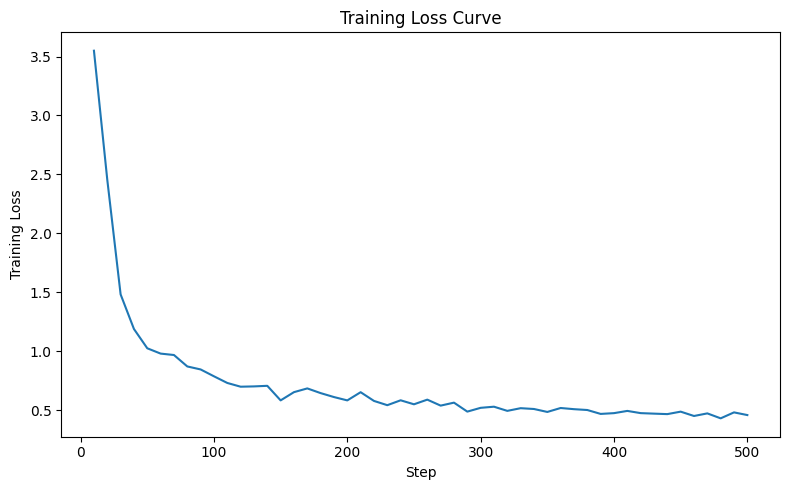

Saved: /content/drive/MyDrive/cisc886-retail-chatbot/training_loss_curve.png


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

logs = trainer.state.log_history
log_df = pd.DataFrame(logs)

log_path = f"{PROJECT_DIR}/training_log.csv"
log_df.to_csv(log_path, index=False)

loss_df = log_df.dropna(subset=["loss"]) if "loss" in log_df.columns else pd.DataFrame()

if not loss_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(loss_df["step"], loss_df["loss"])
    plt.title("Training Loss Curve")
    plt.xlabel("Step")
    plt.ylabel("Training Loss")
    plt.tight_layout()

    fig_path = f"{PROJECT_DIR}/training_loss_curve.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Saved:", fig_path)
else:
    print("No loss values found.")

In [14]:
gguf_dir = f"{PROJECT_DIR}/retail_assistant_gguf"

model.save_pretrained_gguf(
    gguf_dir,
    tokenizer,
    quantization_method="q4_k_m",
)

Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/894 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

...

Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:59<00:00, 59.92s/it]


Unsloth: Merge process complete. Saved to `/content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf_gguf/llama-3.2-1b-instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf_gguf/llama-3.2-1b-instruct.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model /content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf_gguf/llama-3.2-1b-instruct.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to /content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f /content/drive/MyDrive/cisc886-retail-chatbot/retail_assi

{'save_directory': '/content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf',
 'gguf_directory': '/content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf_gguf',
 'gguf_files': ['/content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf_gguf/llama-3.2-1b-instruct.Q4_K_M.gguf'],
 'modelfile_location': '/content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf_gguf/Modelfile',
 'want_full_precision': False,
 'is_vlm': False,
 'fix_bos_token': False}

In [15]:
!ls -lh /content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf_gguf/

total 771M
-rw------- 1 root root 771M Apr 28 15:06 llama-3.2-1b-instruct.Q4_K_M.gguf
-rw------- 1 root root 1.9K Apr 28 15:06 Modelfile


In [16]:
import shutil
from pathlib import Path

src = "/content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf_gguf/llama-3.2-1b-instruct.Q4_K_M.gguf"
dst = "/content/drive/MyDrive/cisc886-retail-chatbot/retail-assistant.Q4_K_M.gguf"

shutil.copy(src, dst)

print("Copied final GGUF to:")
print(dst)
print("Size MB:", round(Path(dst).stat().st_size / 1024 / 1024, 2))

Copied final GGUF to:
/content/drive/MyDrive/cisc886-retail-chatbot/retail-assistant.Q4_K_M.gguf
Size MB: 770.28


In [17]:
!/root/.unsloth/llama.cpp/llama-cli \
  --model /content/drive/MyDrive/cisc886-retail-chatbot/retail-assistant.Q4_K_M.gguf \
  -p "You are a helpful ecommerce shopping assistant. A customer likes WHITE HANGING HEART T-LIGHT HOLDER. Recommend related products." \
  -n 160


Loading model... |-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/-\|/- 


▄▄ ▄▄
██ ██
██ ██  ▀▀█▄ ███▄███▄  ▀▀█▄    ▄████ ████▄ ████▄
██ ██ ▄█▀██ ██ ██ ██ ▄█▀██    ██    ██ ██ ██ ██
██ ██ ▀█▄██ ██ ██ ██ ▀█▄██ ██ ▀████ ████▀ ████▀
                                    ██    ██
                                    ▀▀    ▀▀

build      : b8962-98bb57916
model      : retail-assistant.Q4_K_M.gguf
modalities : text

available commands:
  /exit or Ctrl+C     stop or exit
  /regen              regenerate the last response
  /clear              clear the chat history
  /read <file>        add a text file
  /glob <pattern>     add text files using globbing pattern


> You are a helpful ecommerce shopping assistant. A customer likes WHITE HANGING HEART T-LIGHT HOLDER. Recommend related products.

|-\|/-\|/-\|/-\|/-\|/-\ I have 3 related product(s): 

In [18]:
!find /content/drive/MyDrive/cisc886-retail-chatbot -maxdepth 2 -type f | sort

/content/drive/MyDrive/cisc886-retail-chatbot/base_model_responses.csv
/content/drive/MyDrive/cisc886-retail-chatbot/base_vs_finetuned_responses.csv
/content/drive/MyDrive/cisc886-retail-chatbot/base_vs_finetuned_responses.gsheet
/content/drive/MyDrive/cisc886-retail-chatbot/checkpoints/README.md
/content/drive/MyDrive/cisc886-retail-chatbot/final_lora/adapter_config.json
/content/drive/MyDrive/cisc886-retail-chatbot/final_lora/adapter_model.safetensors
/content/drive/MyDrive/cisc886-retail-chatbot/final_lora/chat_template.jinja
/content/drive/MyDrive/cisc886-retail-chatbot/final_lora/README.md
/content/drive/MyDrive/cisc886-retail-chatbot/final_lora/tokenizer_config.json
/content/drive/MyDrive/cisc886-retail-chatbot/final_lora/tokenizer.json
/content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf/chat_template.jinja
/content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf/config.json
/content/drive/MyDrive/cisc886-retail-chatbot/retail_assistant_gguf_gguf/llama-